#### Efficiency Modeling for Buck Converters with Neural Networks
* Step 1: Exploratory Data Analysis and Data Cleaning
* Step 2: Build Random Forest and XGBoost for Efficiency Modeling (Get Benchmark Base Accuracy)
* Step 3: Develop NNs and Tune their NNs by
    * Apply Standard Scaler to Input Variables
    * Add BatchNorm to the Structure
    * Add Residual Connections
    * Tune Training Epochs
    * Apply Learning Rate Scheduler
    * Tune Hyper-Parameters (Hidden Layer, Hidden Size, Regularization Factor)

#### 0 Load buck converter simulation data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data from the CSV file
data = pd.read_csv("sync_buck_performances_cleaned.csv")

# Remove rows with any NaN values
data = data.dropna()

print(data.shape)
print(data.head())
print(data.describe())

(252, 10)
         f         L         C      pin     pout       eff    ilmax    ilmin  \
0  40000.0  0.000025  0.000092  163.239  98.3538  0.602488  7.50206  1.25485   
1  40000.0  0.000061  0.000092  133.026  98.9822  0.743946  6.58555  3.00313   
2  40000.0  0.000097  0.000092  118.308  99.4059  0.839971  6.10823  3.72128   
3  40000.0  0.000134  0.000092  113.994  99.6323  0.873629  5.85001  4.06366   
4  40000.0  0.000170  0.000092  111.584  99.7767  0.893681  5.68772  4.26300   

      vmax     vmin  
0  20.2828  19.1744  
1  20.1377  19.6001  
2  20.1044  19.7513  
3  20.0882  19.8245  
4  20.0778  19.8681  
             f           L           C         pin        pout         eff  \
count    252.0  252.000000  252.000000  252.000000  252.000000  252.000000   
mean   40000.0    0.000387    0.000179  111.990817   99.944747    0.901868   
std        0.0    0.000220    0.000055   14.578054    0.415726    0.082608   
min    40000.0    0.000025    0.000092  104.679000   98.353800   

#### 1 EDA and Data Cleaning


Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 240 entries, 1 to 251
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f       240 non-null    float64
 1   L       240 non-null    float64
 2   C       240 non-null    float64
 3   pin     240 non-null    float64
 4   pout    240 non-null    float64
 5   eff     240 non-null    float64
 6   ilmax   240 non-null    float64
 7   ilmin   240 non-null    float64
 8   vmax    240 non-null    float64
 9   vmin    240 non-null    float64
dtypes: float64(10)
memory usage: 20.6 KB
None


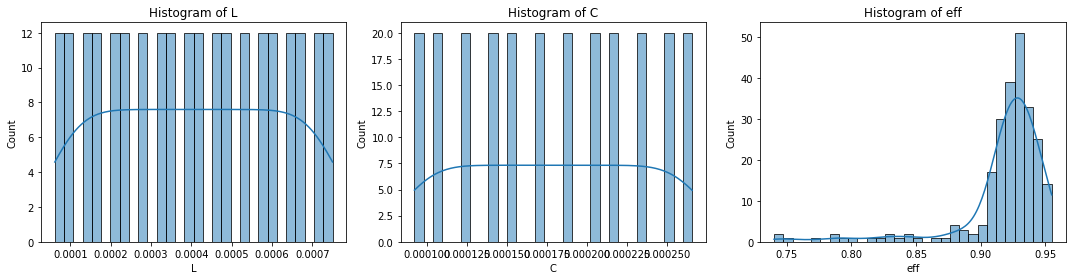

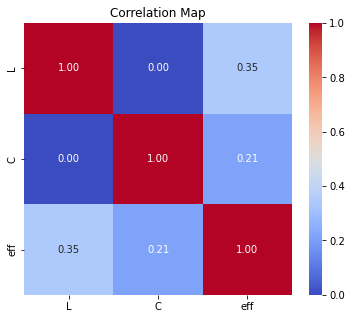

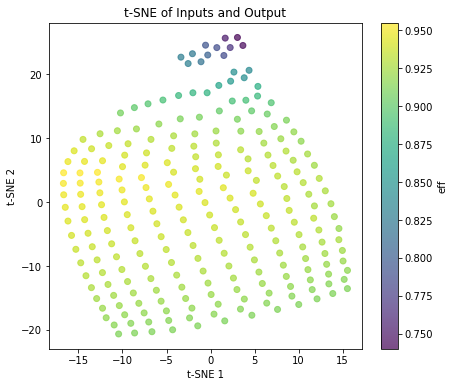

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Remove outliers using Z-score method
def remove_outliers(df, column):
    z_scores = np.abs((df[column] - df[column].mean()) / df[column].std())
    return df[z_scores < 2]  # Remove points more than 3 standard deviations from mean

# # Remove outliers for both output variables
data = remove_outliers(data, 'eff')

# Basic data analysis
print("\nDataset Overview:")
print(data.info())

inputs = ['L', 'C']
output = 'eff'

# Prepare data
X = data[inputs].values.astype(np.float32)
y_eff = data[output].values.astype(np.float32)

# 1. Histograms of inputs and output
fig, axes = plt.subplots(1, len(inputs) + 1, figsize=(15, 4))
for i, col in enumerate(inputs):
    sns.histplot(data[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {col}')
sns.histplot(data[output], bins=30, kde=True, ax=axes[-1])
axes[-1].set_title(f'Histogram of {output}')
plt.tight_layout()
plt.show()

# 2. Correlation map between inputs and output
corr_cols = inputs + [output]
corr = data[corr_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Map')
plt.show()

# 3. t-SNE of combined input and output features
from sklearn.preprocessing import StandardScaler

# Combine input and output for t-SNE
tsne_data = data[inputs + [output]].dropna()
scaler = StandardScaler()
tsne_scaled = scaler.fit_transform(tsne_data)

tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(tsne_scaled)

plt.figure(figsize=(7, 6))
sc = plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=tsne_data[output], cmap='viridis', alpha=0.7)
plt.colorbar(sc, label=output)
plt.title('t-SNE of Inputs and Output')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()


#### 2 Build Random Forest and XGBoost for Efficiency Modeling (Get Benchmark Base Accuracy)

In [3]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Prepare data for efficiency modeling
inputs = ['L', 'C']
output = 'eff'
X = data[inputs].values.astype(np.float32)
y = data[output].values.astype(np.float32)

# Split data into train, val, test (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_train_pred_rf = rf.predict(X_train)
y_val_pred_rf = rf.predict(X_val)
y_test_pred_rf = rf.predict(X_test)

print("Random Forest Train R2: {:.4f}".format(r2_score(y_train, y_train_pred_rf)))
print("Random Forest Validation R2: {:.4f}".format(r2_score(y_val, y_val_pred_rf)))
print("Random Forest Test R2: {:.4f}".format(r2_score(y_test, y_test_pred_rf)))
print("Random Forest Train RMSE: {:.4f}".format(mean_squared_error(y_train, y_train_pred_rf, squared=False)))
print("Random Forest Validation RMSE: {:.4f}".format(mean_squared_error(y_val, y_val_pred_rf, squared=False)))
print("Random Forest Test RMSE: {:.4f}".format(mean_squared_error(y_test, y_test_pred_rf, squared=False)))

# XGBoost Regressor with early stopping
xgb = XGBRegressor(n_estimators=1000, learning_rate=0.05, random_state=42)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    early_stopping_rounds=20,
    verbose=False
)
y_train_pred_xgb = xgb.predict(X_train)
y_val_pred_xgb = xgb.predict(X_val)
y_test_pred_xgb = xgb.predict(X_test)

print("XGBoost Train R2: {:.4f}".format(r2_score(y_train, y_train_pred_xgb)))
print("XGBoost Validation R2: {:.4f}".format(r2_score(y_val, y_val_pred_xgb)))
print("XGBoost Test R2: {:.4f}".format(r2_score(y_test, y_test_pred_xgb)))
print("XGBoost Train RMSE: {:.4f}".format(mean_squared_error(y_train, y_train_pred_xgb, squared=False)))
print("XGBoost Validation RMSE: {:.4f}".format(mean_squared_error(y_val, y_val_pred_xgb, squared=False)))
print("XGBoost Test RMSE: {:.4f}".format(mean_squared_error(y_test, y_test_pred_xgb, squared=False)))


d:\Anaconda\lib\site-packages\xgboost\compat.py:36: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index


Random Forest Train R2: 0.9990
Random Forest Validation R2: 0.9791
Random Forest Test R2: 0.8589
Random Forest Train RMSE: 0.0013
Random Forest Validation RMSE: 0.0038
Random Forest Test RMSE: 0.0046
XGBoost Train R2: 0.9993
XGBoost Validation R2: 0.9826
XGBoost Test R2: 0.9189
XGBoost Train RMSE: 0.0011
XGBoost Validation RMSE: 0.0034
XGBoost Test RMSE: 0.0035


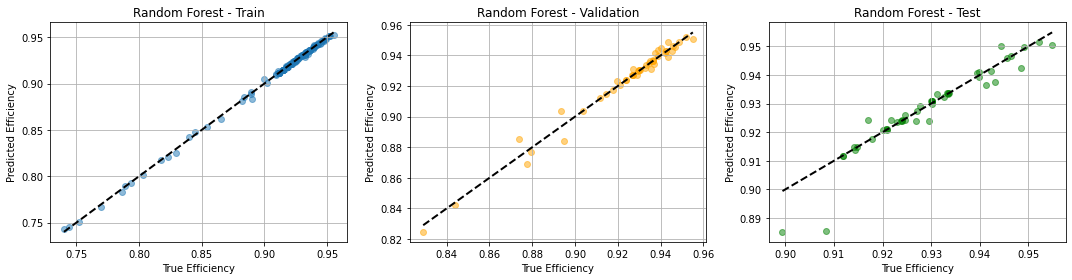

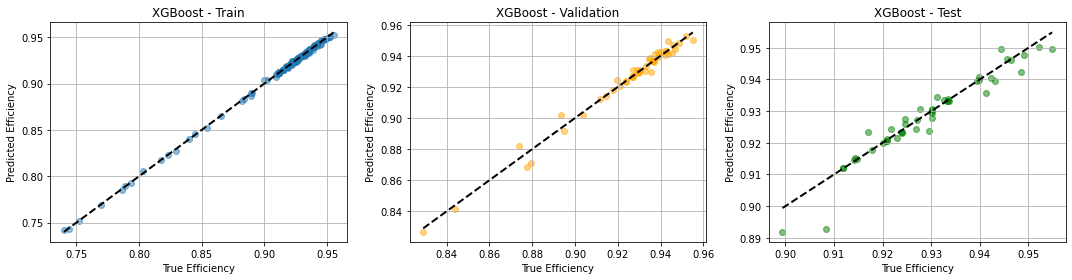

In [4]:
import matplotlib.pyplot as plt

# Plot for Random Forest
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.scatter(y_train, y_train_pred_rf, alpha=0.5, label='Train')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', lw=2)
plt.xlabel('True Efficiency')
plt.ylabel('Predicted Efficiency')
plt.title('Random Forest - Train')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.scatter(y_val, y_val_pred_rf, alpha=0.5, color='orange', label='Validation')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'k--', lw=2)
plt.xlabel('True Efficiency')
plt.ylabel('Predicted Efficiency')
plt.title('Random Forest - Validation')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.scatter(y_test, y_test_pred_rf, alpha=0.5, color='green', label='Test')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('True Efficiency')
plt.ylabel('Predicted Efficiency')
plt.title('Random Forest - Test')
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot for XGBoost
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.scatter(y_train, y_train_pred_xgb, alpha=0.5, label='Train')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', lw=2)
plt.xlabel('True Efficiency')
plt.ylabel('Predicted Efficiency')
plt.title('XGBoost - Train')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.scatter(y_val, y_val_pred_xgb, alpha=0.5, color='orange', label='Validation')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'k--', lw=2)
plt.xlabel('True Efficiency')
plt.ylabel('Predicted Efficiency')
plt.title('XGBoost - Validation')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.scatter(y_test, y_test_pred_xgb, alpha=0.5, color='green', label='Test')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('True Efficiency')
plt.ylabel('Predicted Efficiency')
plt.title('XGBoost - Test')
plt.grid(True)

plt.tight_layout()
plt.show()


#### 3 Apply Standard Scaler to Input Variables

In [5]:
import torch

# Use the same train/val/test split as in the main context
inputs = ['L', 'C']
output = 'eff'
X = data[inputs].values.astype(np.float32)
y = data[output].values.astype(np.float32)

# Use the same split as in file_context_0
from sklearn.model_selection import train_test_split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import mean_absolute_error

batch_size = 150
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


# Feedforward Neural Network with Residual Connections and BatchNorm
class FeedforwardNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_layers=2):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.input_bn = nn.BatchNorm1d(hidden_dim)
        self.input_act = nn.Tanh()

        self.hidden_layers = nn.ModuleList()
        self.hidden_bns = nn.ModuleList()
        self.hidden_acts = nn.ModuleList()
        self.residuals = nn.ModuleList()
        for _ in range(num_layers - 1):
            self.hidden_layers.append(nn.Linear(hidden_dim, hidden_dim))
            self.hidden_bns.append(nn.BatchNorm1d(hidden_dim))
            self.hidden_acts.append(nn.Tanh())
            # If hidden_dim matches, use identity for residual, else use Linear
            if hidden_dim == hidden_dim:
                self.residuals.append(nn.Identity())
            else:
                self.residuals.append(nn.Linear(hidden_dim, hidden_dim))

        self.output_layer = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out = self.input_layer(x)
        out = self.input_bn(out)
        out = self.input_act(out)
        for i in range(self.num_layers - 1):
            residual = out
            out = self.hidden_layers[i](out)
            out = self.hidden_bns[i](out)
            out = self.hidden_acts[i](out)
            out = out + self.residuals[i](residual)
        out = self.output_layer(out)
        return out


input_dim = X_train_t.shape[1]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FeedforwardNN(input_dim=input_dim, hidden_dim=64, num_layers=2).to(device)
criterion = nn.MSELoss()


n_epochs = 2000


# Apply L2 regularization (weight decay) via optimizer
l2_lambda = 1e-3  # You can adjust this value as needed
optimizer = optim.Adam(model.parameters(), lr=0.02, weight_decay=l2_lambda)

# Reference-style learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=50, verbose=True, min_lr=1e-4)
    

best_val_loss = float('inf')
best_model_state = None

train_loss_history = []
val_loss_history = []

for epoch in range(n_epochs):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    train_loss = np.mean(train_losses)
    # Validation
    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            val_losses.append(loss.item())
    val_loss = np.mean(val_losses)
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    if scheduler is not None:
        scheduler.step(val_loss)
    # Save best model based on minimal validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
    if (epoch+1) % 50 == 0 or epoch == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4e}, Val Loss={val_loss:.4e}, LR={current_lr:.2e}")

# Load best model
model.load_state_dict(best_model_state)
model.eval()

# Evaluate R2 and RMSE on all three datasets, scaling predictions back to original efficiency
from sklearn.metrics import r2_score, mean_squared_error

def get_preds_and_targets_unscaled(loader, scaler_y):
    preds = []
    targets = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            preds.append(pred)
            targets.append(yb.cpu().numpy())
    preds = np.vstack(preds).squeeze()
    targets = np.vstack(targets).squeeze()
    # Inverse transform predictions and ground truth to original scale if scaler_y is not None
    if scaler_y is not None:
        preds_unscaled = scaler_y.inverse_transform(preds.reshape(-1, 1)).squeeze()
        targets_unscaled = scaler_y.inverse_transform(targets.reshape(-1, 1)).squeeze()
    else:
        preds_unscaled = preds
        targets_unscaled = targets
    return preds_unscaled, targets_unscaled

# Get predictions and ground truth for each split (unscaled)
y_train_pred_unscaled, y_train_true_unscaled = get_preds_and_targets_unscaled(train_loader, scaler_y)
y_val_pred_unscaled, y_val_true_unscaled = get_preds_and_targets_unscaled(val_loader, scaler_y)
y_test_pred_unscaled, y_test_true_unscaled = get_preds_and_targets_unscaled(test_loader, scaler_y)

# Compute metrics
r2_train = r2_score(y_train_true_unscaled, y_train_pred_unscaled)
rmse_train = mean_squared_error(y_train_true_unscaled, y_train_pred_unscaled, squared=False)
r2_val = r2_score(y_val_true_unscaled, y_val_pred_unscaled)
rmse_val = mean_squared_error(y_val_true_unscaled, y_val_pred_unscaled, squared=False)
r2_test = r2_score(y_test_true_unscaled, y_test_pred_unscaled)
rmse_test = mean_squared_error(y_test_true_unscaled, y_test_pred_unscaled, squared=False)

print(f"Train set:    R2 = {r2_train:.4f}, RMSE = {rmse_train:.4f}")
print(f"Validation:   R2 = {r2_val:.4f}, RMSE = {rmse_val:.4f}")
print(f"Test set:     R2 = {r2_test:.4f}, RMSE = {rmse_test:.4f}")


d:\Anaconda\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1: Train Loss=8.9888e-01, Val Loss=1.7952e+00, LR=2.00e-02
Epoch 50: Train Loss=2.8542e-01, Val Loss=1.2177e-01, LR=2.00e-02
Epoch 100: Train Loss=2.9276e-02, Val Loss=7.8433e-02, LR=2.00e-02
Epoch 150: Train Loss=6.9417e-03, Val Loss=7.2485e-03, LR=2.00e-02
Epoch 200: Train Loss=7.4211e-03, Val Loss=7.1488e-03, LR=2.00e-02
Epoch 250: Train Loss=9.2706e-03, Val Loss=1.5180e-02, LR=2.00e-02
Epoch 300: Train Loss=3.7850e-03, Val Loss=5.7272e-03, LR=1.00e-02
Epoch 350: Train Loss=3.4783e-03, Val Loss=6.3337e-03, LR=1.00e-02
Epoch 400: Train Loss=3.5850e-03, Val Loss=1.0267e-02, LR=1.00e-02
Epoch 450: Train Loss=3.3767e-03, Val Loss=3.7342e-03, LR=5.00e-03
Epoch 500: Train Loss=3.1764e-03, Val Loss=3.7431e-03, LR=2.50e-03
Epoch 550: Train Loss=3.1364e-03, Val Loss=3.5562e-03, LR=1.25e-03
Epoch 600: Train Loss=3.1749e-03, Val Loss=3.5377e-03, LR=6.25e-04
Epoch 650: Train Loss=3.1226e-03, Val Loss=3.5176e-03, LR=3.13e-04
Epoch 700: Train Loss=3.1123e-03, Val Loss=3.4637e-03, LR=1.56e-0

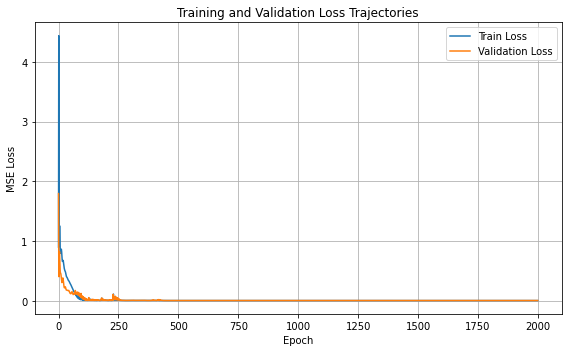

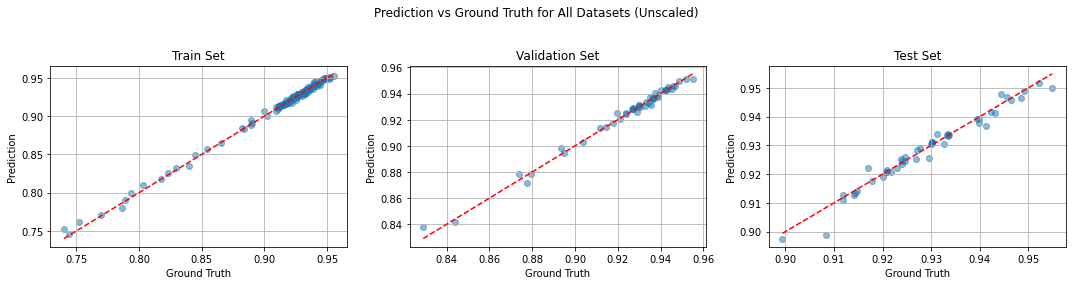

In [7]:
import matplotlib.pyplot as plt

# 1. Plot the training and validation loss trajectories
plt.figure(figsize=(8,5))
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss Trajectories')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Correct prediction vs ground-truth plots for all datasets (unscaled)
def get_preds_and_targets_unscaled(loader, y_full, scaler_y):
    preds = []
    targets = []
    idx = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            preds.append(pred)
            # yb is already a batch of targets (scaled)
            targets.append(yb.cpu().numpy())
            idx += len(xb)
    preds = np.vstack(preds).squeeze()
    targets = np.vstack(targets).squeeze()
    # Inverse transform predictions and ground truth to original scale if scaler_y is not None
    if scaler_y is not None:
        preds_unscaled = scaler_y.inverse_transform(preds.reshape(-1, 1)).squeeze()
        targets_unscaled = scaler_y.inverse_transform(targets.reshape(-1, 1)).squeeze()
    else:
        preds_unscaled = preds
        targets_unscaled = targets
    return preds_unscaled, targets_unscaled

# Get predictions and ground truth for each split
y_train_pred_unscaled, y_train_true_unscaled = get_preds_and_targets_unscaled(train_loader, y_train, scaler_y)
y_val_pred_unscaled, y_val_true_unscaled = get_preds_and_targets_unscaled(val_loader, y_val, scaler_y)
y_test_pred_unscaled, y_test_true_unscaled = get_preds_and_targets_unscaled(test_loader, y_test, scaler_y)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.scatter(y_train_true_unscaled, y_train_pred_unscaled, alpha=0.5)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title('Train Set')
plt.plot([y_train_true_unscaled.min(), y_train_true_unscaled.max()],
         [y_train_true_unscaled.min(), y_train_true_unscaled.max()], 'r--')
plt.grid(True)

plt.subplot(1,3,2)
plt.scatter(y_val_true_unscaled, y_val_pred_unscaled, alpha=0.5)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title('Validation Set')
plt.plot([y_val_true_unscaled.min(), y_val_true_unscaled.max()],
         [y_val_true_unscaled.min(), y_val_true_unscaled.max()], 'r--')
plt.grid(True)

plt.subplot(1,3,3)
plt.scatter(y_test_true_unscaled, y_test_pred_unscaled, alpha=0.5)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title('Test Set')
plt.plot([y_test_true_unscaled.min(), y_test_true_unscaled.max()],
         [y_test_true_unscaled.min(), y_test_true_unscaled.max()], 'r--')
plt.grid(True)

plt.suptitle('Prediction vs Ground Truth for All Datasets (Unscaled)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


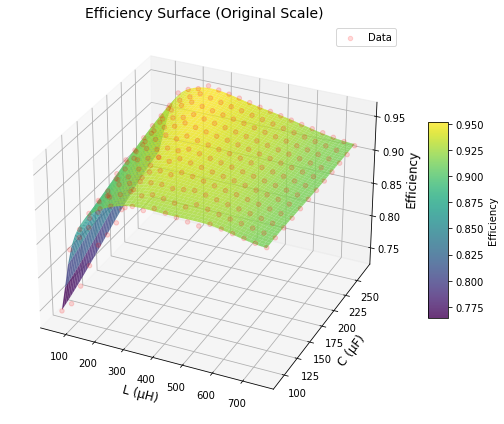

In [8]:
# Plot the surface of efficiency in original scale with respect to L and C

# Here we assume you have a trained model, and possibly scalers for L, C, and efficiency (scaler_X, scaler_y)
# We'll create a meshgrid of L and C in the original scale, predict efficiency, and plot the surface

# Define the range for L and C in original scale (adjust as appropriate for your data)
L_min, L_max = data['L'].min(), data['L'].max()
C_min, C_max = data['C'].min(), data['C'].max()

L_vals = np.linspace(L_min, L_max, 50)
C_vals = np.linspace(C_min, C_max, 50)
L_mesh, C_mesh = np.meshgrid(L_vals, C_vals)

# Prepare input for the model: flatten meshgrid, stack, scale if needed
LC_grid = np.stack([L_mesh.ravel(), C_mesh.ravel()], axis=1)
if scaler_X is not None:
    LC_grid_model = scaler_X.transform(LC_grid)
else:
    LC_grid_model = LC_grid

# Predict efficiency (in scaled or unscaled space), then inverse transform to original scale if needed
with torch.no_grad():
    LC_tensor = torch.tensor(LC_grid_model, dtype=torch.float32).to(device)
    eff_pred = model(LC_tensor).cpu().numpy().reshape(-1, 1)
    if scaler_y is not None:
        eff_pred_unscaled = scaler_y.inverse_transform(eff_pred).reshape(L_mesh.shape)
    else:
        eff_pred_unscaled = eff_pred.reshape(L_mesh.shape)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(L_mesh*1e6, C_mesh*1e6, eff_pred_unscaled, cmap='viridis', alpha=0.8, edgecolor='none', antialiased=True)

# Add scattered points from the original data
# Convert L and C to microhenries and microfarads for plotting
L_points = data['L'].values * 1e6
C_points = data['C'].values * 1e6
eff_points = data['eff'].values
ax.scatter(L_points, C_points, eff_points, color='r', s=20, label='Data', alpha=0.15)

ax.set_xlabel('L (µH)', fontsize=12)
ax.set_ylabel('C (µF)', fontsize=12)
ax.set_zlabel('Efficiency', fontsize=12)
ax.set_title('Efficiency Surface (Original Scale)', fontsize=14)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Efficiency')
ax.view_init(elev=30, azim=-65)
ax.legend()
plt.tight_layout()
plt.show()
